# Retail Sales Analysis & Prediction Project

## Objective

Analyze retail sales data, discover patterns, and build a model to predict sales.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

records = 1000


order_id = range(1001,1001+records)


date = pd.date_range(
    start="2025-01-01",
    periods=records
)


product = np.random.choice(
    [
        "Laptop",
        "Mobile",
        "Headphones",
        "Shoes",
        "Watch"
    ],
    records
)


category = np.random.choice(
    [
        "Electronics",
        "Fashion",
        "Accessories"
    ],
    records
)


region = np.random.choice(
    [
        "North",
        "South",
        "East",
        "West"
    ],
    records
)


quantity = np.random.randint(
    1,
    10,
    records
)


price = np.random.randint(
    500,
    50000,
    records
)


discount = np.random.randint(
    0,
    40,
    records
)


rating = np.random.randint(
    1,
    6,
    records
)


total_sales = (
    quantity * price
    -
    (quantity * price * discount/100)
)

In [3]:
df = pd.DataFrame({

    "Order_ID": order_id,
    "Date": date,
    "Product": product,
    "Category": category,
    "Region": region,
    "Quantity": quantity,
    "Price": price,
    "Discount": discount,
    "Customer_Rating": rating,
    "Total_Sales": total_sales

})


df.head()

,Order_ID,Date,Product,Category,Region,Quantity,Price,Discount,Customer_Rating,Total_Sales
0,1001,2025-01-01,Shoes,Electronics,North,4,19101,32,2,51954.72
1,1002,2025-01-02,Watch,Electronics,South,1,5467,14,1,4701.62
2,1003,2025-01-03,Headphones,Accessories,West,9,19253,11,5,154216.53
3,1004,2025-01-04,Watch,Fashion,East,6,20522,39,3,75110.52
4,1005,2025-01-05,Watch,Electronics,West,1,43963,19,5,35610.03


In [4]:
df.to_csv(
    "retail_sales_data.csv",
    index=False
)

print("Dataset saved!")

Dataset saved!


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         1000 non-null   int64         
 1   Date             1000 non-null   datetime64[ns]
 2   Product          1000 non-null   object        
 3   Category         1000 non-null   object        
 4   Region           1000 non-null   object        
 5   Quantity         1000 non-null   int64         
 6   Price            1000 non-null   int64         
 7   Discount         1000 non-null   int64         
 8   Customer_Rating  1000 non-null   int64         
 9   Total_Sales      1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 78.3+ KB


In [6]:
df.isnull().sum()

,0
Order_ID,0
Date,0
Product,0
Category,0
Region,0
Quantity,0
Price,0
Discount,0
Customer_Rating,0
Total_Sales,0


In [7]:
df.describe()

,Order_ID,Date,Quantity,Price,Discount,Customer_Rating,Total_Sales
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,2026-05-15 12:00:00,5.017000,25326.172000,19.757000,2.952000,103908.706320
min,1001.000000,2025-01-01 00:00:00,1.000000,582.000000,0.000000,1.000000,636.640000
25%,1250.750000,2025-09-07 18:00:00,3.000000,13345.250000,11.000000,2.000000,32089.672500
50%,1500.500000,2026-05-15 12:00:00,5.000000,25548.000000,19.000000,3.000000,82731.490000
75%,1750.250000,2027-01-20 06:00:00,7.000000,37011.250000,30.000000,4.000000,152072.267500
max,2000.000000,2027-09-27 00:00:00,9.000000,49930.000000,39.000000,5.000000,412070.400000
std,288.819436,NaN,2.591414,14126.666358,11.361824,1.417641,86578.702147


In [9]:
df["Month"] = df["Date"].dt.month

In [10]:
monthly_sales = df.groupby(
    "Month"
)["Total_Sales"].sum()


monthly_sales

,Total_Sales
Month,
1,9276282.90
2,9004928.30
3,8738866.26
4,9598241.18
5,10410354.99
6,9836697.61
7,9393459.78
8,8603384.26
9,9091271.21


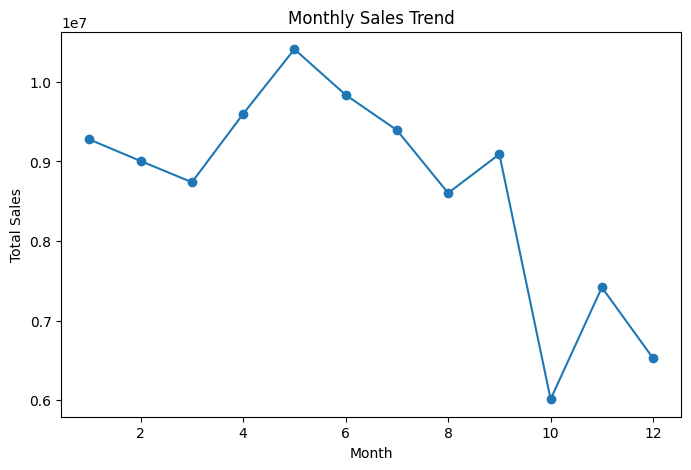

In [11]:
plt.figure(figsize=(8,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Sales Trend"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Total Sales"
)

plt.show()

In [12]:
category_sales = df.groupby(
    "Category"
)["Total_Sales"].sum()


category_sales

,Total_Sales
Category,
Accessories,32528975.63
Electronics,33861045.59
Fashion,37518685.10


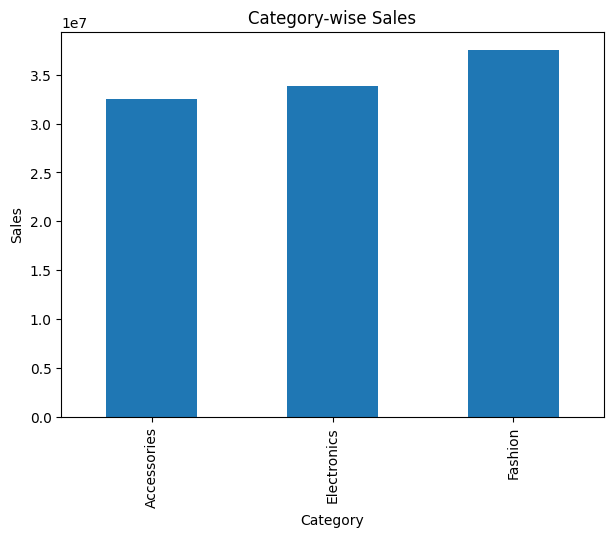

In [13]:
plt.figure(figsize=(7,5))

category_sales.plot(
    kind="bar"
)

plt.title(
    "Category-wise Sales"
)

plt.xlabel(
    "Category"
)

plt.ylabel(
    "Sales"
)

plt.show()

In [14]:
region_sales = df.groupby(
    "Region"
)["Total_Sales"].sum()


region_sales

,Total_Sales
Region,
East,21326286.07
North,27276744.65
South,26213055.45
West,29092620.15


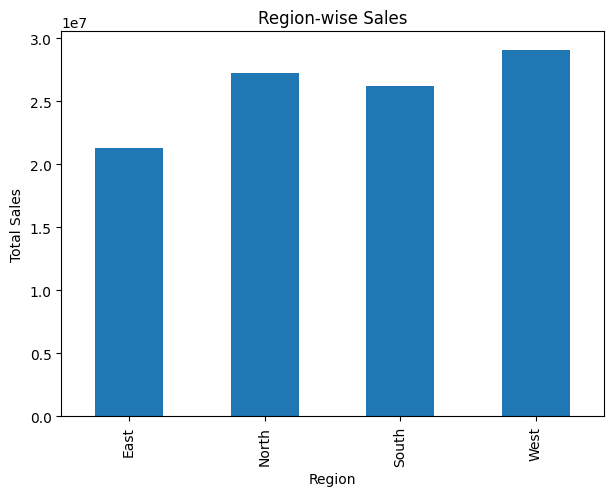

In [15]:
plt.figure(figsize=(7,5))

region_sales.plot(
    kind="bar"
)

plt.title(
    "Region-wise Sales"
)

plt.xlabel(
    "Region"
)

plt.ylabel(
    "Total Sales"
)

plt.show()

In [16]:
numeric_data = df[
    [
        "Quantity",
        "Price",
        "Discount",
        "Customer_Rating",
        "Total_Sales"
    ]
]

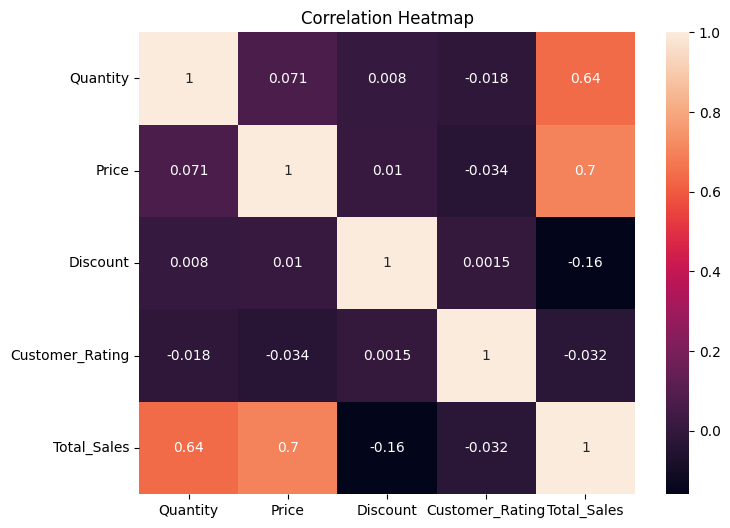

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [18]:
X = df[
    [
        "Quantity",
        "Price",
        "Discount",
        "Customer_Rating"
    ]
]


y = df["Total_Sales"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = LinearRegression()


model.fit(
    X_train,
    y_train
)


print("Model trained successfully!")

Model trained successfully!


In [21]:
model = LinearRegression()


model.fit(
    X_train,
    y_train
)


print("Model trained successfully!")

Model trained successfully!


In [22]:
y_pred = model.predict(
    X_test
)

In [23]:
mae = mean_absolute_error(
    y_test,
    y_pred
)


r2 = r2_score(
    y_test,
    y_pred
)


print(
    "Mean Absolute Error:",
    mae
)


print(
    "R2 Score:",
    r2
)

Mean Absolute Error: 22661.725163786075
R2 Score: 0.8819078171372066


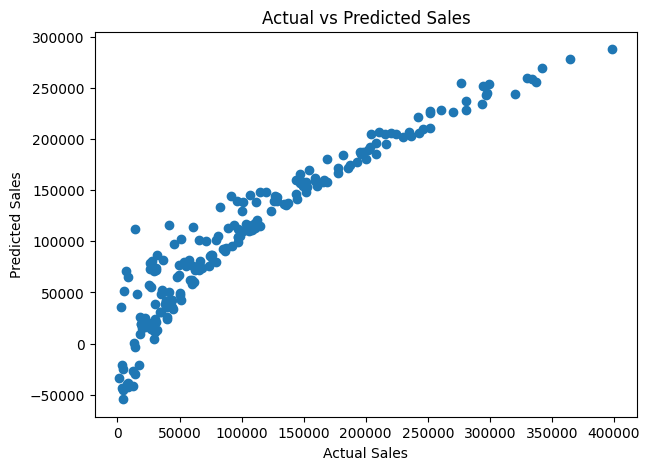

In [24]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

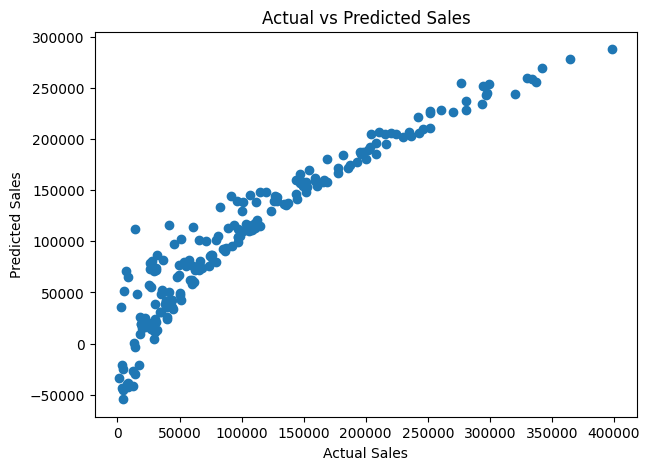

In [25]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.show()

# Key Insights

- Sales vary across different product categories.
- Some regions generate higher sales than others.
- Quantity and price strongly influence total sales.
- The Linear Regression model predicts sales with good accuracy.

# Conclusion

This project analyzed retail sales data and built a Linear Regression model to predict total sales.

The analysis included data exploration, visualization, correlation analysis, and prediction, demonstrating an end-to-end real-world data science workflow.

In [26]:
from google.colab import files

files.download("retail_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>